# Distribution Explorer
Visualizes all distributions used in `DistributionConfig` with adjustable parameters.

**Install deps if needed:** `pip install numpy matplotlib scipy`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

SEED = 42
N = 10_000
rng = np.random.default_rng(SEED)

## Parameters — tweak these

In [21]:
# Uniform
UNIFORM_LOW, UNIFORM_HIGH = 0, 1000

# Normal
NORMAL_MEAN, NORMAL_STD = 500, 100

# Log-Normal (parameters are for the underlying normal)
LOGNORM_MEAN, LOGNORM_STD = 4.0, 0.8   # exp(mean) ~ 55 will be center

# Zipfian — a controls skew. lower = heavier tail
# 1.2 = very heavy (realistic web/query workloads)
# 2.0 = moderate skew
ZIPF_A = 1.5
ZIPF_CLIP = 200   # clip extreme outliers for readability

# Poisson
POISSON_LAMBDA = 5.0

# Clustered
CLUSTER_N      = 5       # number of cluster centers
CLUSTER_SPREAD = 30      # std dev around each center
CLUSTER_DOMAIN = (0, 1000)

## Generate Samples

In [22]:
uniform_samples = rng.integers(UNIFORM_LOW, UNIFORM_HIGH, N)

normal_samples = rng.normal(NORMAL_MEAN, NORMAL_STD, N).astype(int)

lognorm_samples = rng.lognormal(LOGNORM_MEAN, LOGNORM_STD, N).astype(int)

# numpy zipf requires a > 1
zipf_samples = rng.zipf(ZIPF_A, N)
zipf_samples = zipf_samples[zipf_samples <= ZIPF_CLIP]   # remove extreme tail for plot

poisson_samples = rng.poisson(POISSON_LAMBDA, N)

# Clustered: pick random centers, then sample normally around each
centers = rng.integers(*CLUSTER_DOMAIN, CLUSTER_N)
chosen  = rng.choice(centers, N)
clustered_samples = (chosen + rng.normal(0, CLUSTER_SPREAD, N)).astype(int)
clustered_samples = np.clip(clustered_samples, *CLUSTER_DOMAIN)

print("Sample counts (after clipping):")
for name, s in [("Uniform", uniform_samples), ("Normal", normal_samples),
                ("LogNormal", lognorm_samples), ("Zipfian", zipf_samples),
                ("Poisson", poisson_samples), ("Clustered", clustered_samples)]:
    print(f"  {name:12s}: {len(s):>6,}  mean={np.mean(s):.1f}  median={np.median(s):.1f}  max={np.max(s)}")

Sample counts (after clipping):
  Uniform     : 10,000  mean=500.7  median=504.5  max=999
  Normal      : 10,000  mean=500.7  median=501.0  max=869
  LogNormal   : 10,000  mean=75.3  median=55.0  max=1483
  Zipfian     :  9,438  mean=11.1  median=2.0  max=200
  Poisson     : 10,000  mean=5.0  median=5.0  max=15
  Clustered   : 10,000  mean=497.4  median=596.0  max=999


## Plot All Distributions

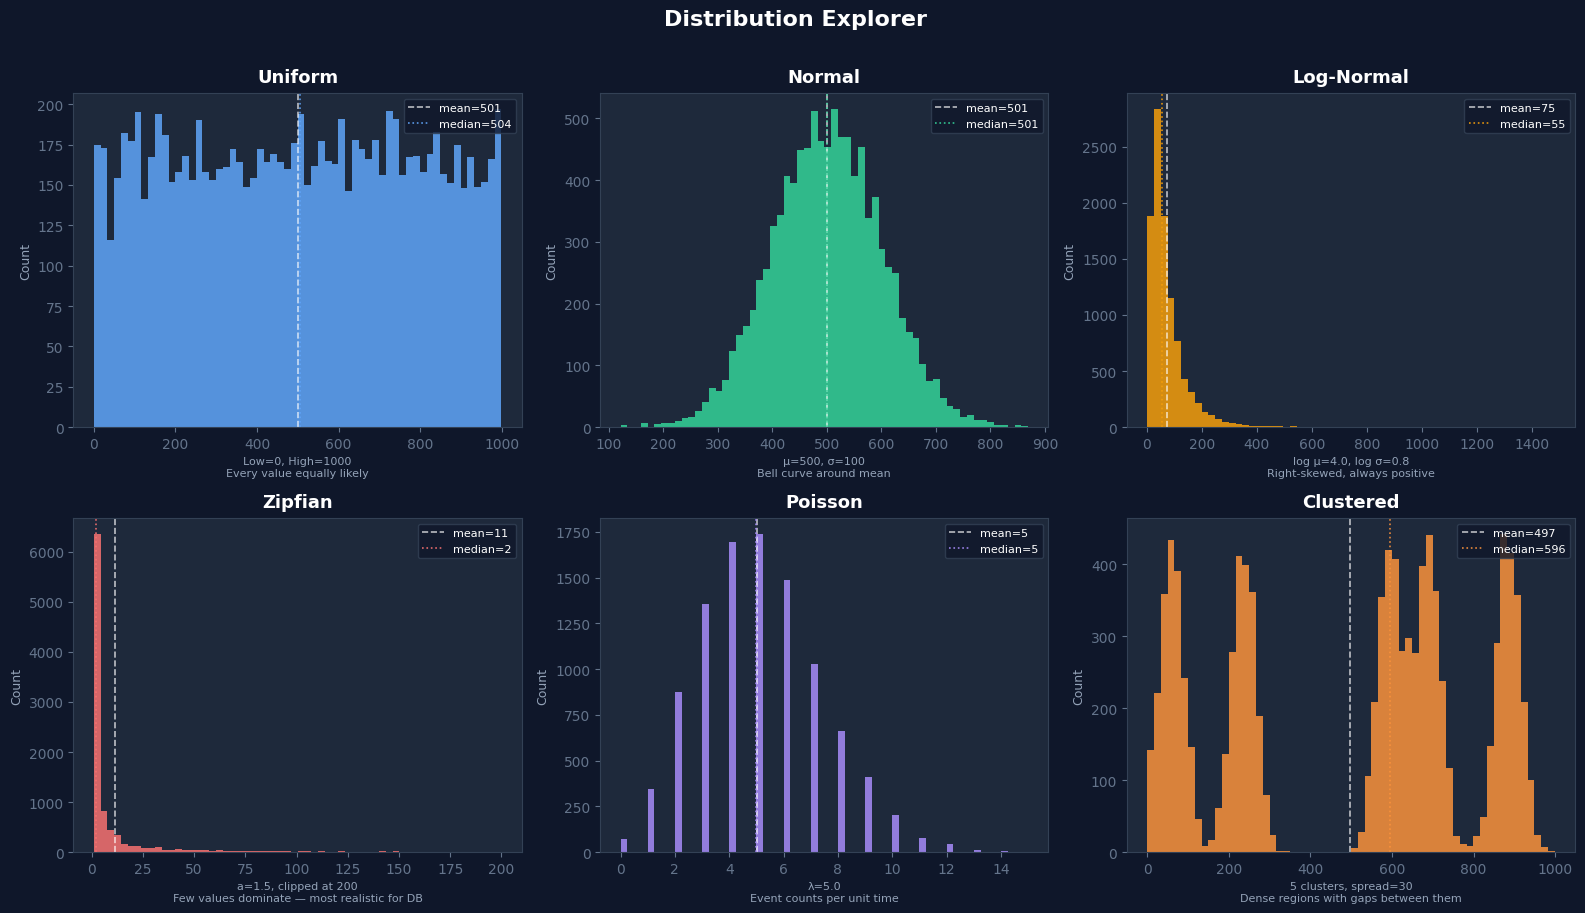

In [25]:
COLORS = ["#60a5fa", "#34d399", "#f59e0b", "#f87171", "#a78bfa", "#fb923c"]

distributions = [
    ("Uniform",   uniform_samples,   f"Low={UNIFORM_LOW}, High={UNIFORM_HIGH}\nEvery value equally likely"),
    ("Normal",    normal_samples,    f"μ={NORMAL_MEAN}, σ={NORMAL_STD}\nBell curve around mean"),
    ("Log-Normal",lognorm_samples,   f"log μ={LOGNORM_MEAN}, log σ={LOGNORM_STD}\nRight-skewed, always positive"),
    ("Zipfian",   zipf_samples,      f"a={ZIPF_A}, clipped at {ZIPF_CLIP}\nFew values dominate — most realistic for DB"),
    ("Poisson",   poisson_samples,   f"λ={POISSON_LAMBDA}\nEvent counts per unit time"),
    ("Clustered", clustered_samples, f"{CLUSTER_N} clusters, spread={CLUSTER_SPREAD}\nDense regions with gaps between them"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor("#0f172a")
axes = axes.flatten()

for ax, (name, samples, desc), color in zip(axes, distributions, COLORS):
    ax.set_facecolor("#1e293b")
    ax.hist(samples, bins=60, color=color, alpha=0.85, edgecolor="none")

    # mean line
    ax.axvline(np.mean(samples), color="white", linewidth=1.2, linestyle="--", alpha=0.7, label=f"mean={np.mean(samples):.0f}")
    ax.axvline(np.median(samples), color=color, linewidth=1.2, linestyle=":", alpha=0.9, label=f"median={np.median(samples):.0f}")

    ax.set_title(name, color="white", fontsize=13, fontweight="bold", pad=8)
    ax.set_xlabel(desc, color="#94a3b8", fontsize=8)
    ax.set_ylabel("Count", color="#94a3b8", fontsize=9)
    ax.tick_params(colors="#64748b")
    for spine in ax.spines.values():
        spine.set_edgecolor("#334155")
    ax.legend(fontsize=8, labelcolor="white", facecolor="#0f172a", edgecolor="#334155")

fig.suptitle("Distribution Explorer", color="white", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
# plt.savefig("distributions_overview.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
# print("Saved: distributions_overview.png")

## Zipfian Deep Dive
Zipfian is the most important for DB research — worth looking at more carefully.

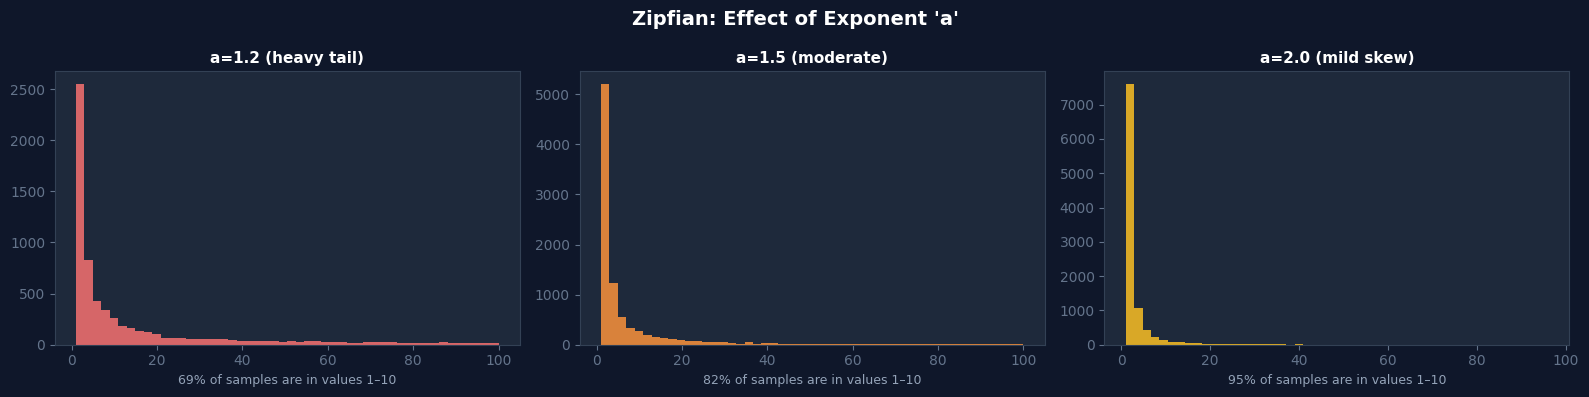

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_facecolor("#0f172a")

a_values = [1.2, 1.5, 2.0]
labels   = ["a=1.2 (heavy tail)", "a=1.5 (moderate)", "a=2.0 (mild skew)"]
colors   = ["#f87171", "#fb923c", "#fbbf24"]

for ax, a, label, color in zip(axes, a_values, labels, colors):
    ax.set_facecolor("#1e293b")
    s = rng.zipf(a, N)
    s = s[s <= 100]
    ax.hist(s, bins=50, color=color, alpha=0.85, edgecolor="none")
    
    # annotate what % of data is in top-10 values
    top10_pct = np.sum(s <= 10) / len(s) * 100
    ax.set_title(label, color="white", fontsize=11, fontweight="bold")
    ax.set_xlabel(f"{top10_pct:.0f}% of samples are in values 1–10", color="#94a3b8", fontsize=9)
    ax.tick_params(colors="#64748b")
    for spine in ax.spines.values():
        spine.set_edgecolor("#334155")

fig.suptitle("Zipfian: Effect of Exponent 'a'", color="white", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("zipfian_deep_dive.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

## Interval Width Distribution
How each distribution affects the *width* of generated intervals — directly relevant to your SUM aggregation stress testing.

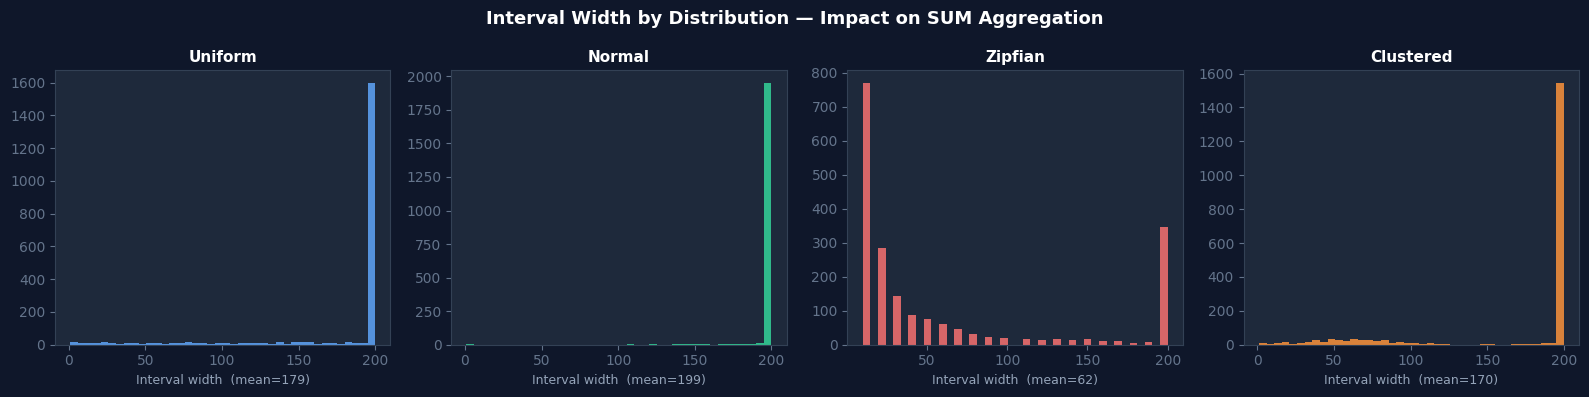

In [29]:
def generate_intervals(sampler, n=2000):
    """Generate (lb, ub) pairs using sampler for lb, then sample width on top."""
    intervals = []
    for _ in range(n):
        lb = int(np.clip(sampler(), 0, 900))
        width = int(np.clip(sampler(), 1, 200))
        intervals.append((lb, lb + width))
    return intervals

interval_sets = {
    "Uniform":   generate_intervals(lambda: rng.integers(0, 1000)),
    "Normal":    generate_intervals(lambda: rng.normal(500, 150)),
    "Zipfian":   generate_intervals(lambda: rng.zipf(1.5) * 10),
    "Clustered": generate_intervals(lambda: rng.choice(centers) + rng.normal(0, 30)),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.patch.set_facecolor("#0f172a")
colors = ["#60a5fa", "#34d399", "#f87171", "#fb923c"]

for ax, (name, intervals), color in zip(axes, interval_sets.items(), colors):
    ax.set_facecolor("#1e293b")
    widths = [ub - lb for lb, ub in intervals]
    ax.hist(widths, bins=40, color=color, alpha=0.85, edgecolor="none")
    ax.set_title(name, color="white", fontsize=11, fontweight="bold")
    ax.set_xlabel(f"Interval width  (mean={np.mean(widths):.0f})", color="#94a3b8", fontsize=9)
    ax.tick_params(colors="#64748b")
    for spine in ax.spines.values():
        spine.set_edgecolor("#334155")

fig.suptitle("Interval Width by Distribution — Impact on SUM Aggregation", color="white", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("interval_widths.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

In [39]:
def generate_intervals2(sampler, n=10):
    """Generate (lb, ub) pairs using sampler for lb, then sample width on top."""
    intervals = []
    for _ in range(n):
        lb = int(np.clip(sampler(), 0, 900))
        # width = 
        width = int(np.clip(sampler(), 1, 200))
        # width = 0
        intervals.append((lb, lb + width))
    return intervals

interval_sets = {
    "Uniform":   generate_intervals2(lambda: rng.integers(0, 1000)),
    "Normal":    generate_intervals2(lambda: rng.normal(500, 150)),
    "Zipfian":   generate_intervals2(lambda: rng.zipf(1.5) * 10),
    "Clustered": generate_intervals2(lambda: rng.choice(centers) + rng.normal(0, 30)),
}

for d, s in interval_sets.items():
    print(d)
    print(s)

Uniform
[(468, 668), (42, 242), (789, 989), (841, 1041), (680, 880), (900, 1100), (812, 1012), (735, 935), (160, 360), (726, 926)]
Normal
[(642, 842), (548, 748), (801, 1001), (235, 435), (394, 594), (681, 881), (630, 830), (591, 791), (478, 678), (495, 695)]
Zipfian
[(60, 260), (10, 210), (900, 910), (10, 210), (30, 40), (20, 30), (20, 60), (10, 90), (20, 220), (30, 90)]
Clustered
[(866, 1066), (867, 1067), (649, 849), (698, 898), (219, 304), (106, 306), (671, 871), (615, 815), (252, 325), (835, 914)]


In [45]:
def generate_range_in(interval_size_range= (1, 1000), n=10):
        # # uncertain ratio. maybe should account for half nulls, half mult 0
        # if np.random.random() < experiment.uncertain_ratio * 0.5:  
        #     return RangeType(0, 0, True)

    intervals = []
    for _ in range(n):
        lb = np.random.randint(*interval_size_range)
        ub = np.random.randint(lb+1, interval_size_range[1]+1)

        # protect against mistakes or future changes
        if lb > ub:
            lb, ub = ub, lb
        # return (lb, ub)
        intervals.append((lb, ub))
    return intervals

a = generate_range()
a

[(44, 648),
 (265, 887),
 (805, 901),
 (174, 255),
 (363, 394),
 (37, 144),
 (330, 349),
 (128, 349),
 (381, 759),
 (150, 680)]

In [ ]:
def generate_set_in(interval_size_range= (1, 1000), n=10):
        
        # # if experiment.num_intervals is not None then use, otherwise if experiment.num_intervals_range then use. otherwise raise error
        # if experiment.num_intervals is not None:
        #     num_intervals = experiment.num_intervals
        # elif experiment.num_intervals_range is not None:
        #     num_intervals = np.random.randint(*experiment.num_intervals_range)
        # else:
        #     raise ValueError("Either num_intervals or num_intervals_range must be specified")
        
        # entire set is unknown
        # if np.random.random() < experiment.uncertain_ratio * 0.5:  
        #     return RangeSetType([], cu=False)
        
        rset = []

        # set the first starting point
        # if experiment.start_interval_range is not None:
        #     start = np.random.randint(*experiment.start_interval_range)
        # else:
        #     start = experiment.interval_size_range[0]
        start = np.random.randint(*interval_size_range)

        # for each interval
        for i in range(n):    
            # if np.random.random() < experiment.uncertain_ratio * 0.5:  
            #     continue
            
            # # get the interval width
            # if experiment.interval_width is not None:
            #     interval_width = experiment.interval_width
            # elif experiment.interval_width_range is not None:
            #     interval_width = np.random.randint(*experiment.interval_width_range)
            # else:
            #     raise ValueError("Either interval_width or interval_width_range must be specified")
            interval_end = start + max(1, interval_width)
            
            # should never trigger, incase does
            if interval_end <= start:
                print(f"BAD RANGE: start={start}, interval_end={interval_end}, width={interval_width}, i={i}")
                rset.append(RangeType([], interval_end, False))  
            else:     
                rset.append(RangeType(start, interval_end, False))

            # find next gap if not last
            if i < num_intervals -1:
                if experiment.gap_size is not None:
                    gap = experiment.gap_size
                elif experiment.gap_size_range is not None:
                    gap = np.random.randint(*experiment.gap_size_range)
                else:
                    gap = 0  
                
                start = interval_end + gap

            # next next start exceeds bounds, we can't add more intervals
            if experiment.domain_max is not None and start >= experiment.domain_max:
                break
        

        return RangeSetType(rset, cu=False)